## GÜN 1

Sadece veri setini tanımak için inceleme

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv("C:\\Users\\mete1\\regression-pipeline\\data\\train.csv")

In [50]:
df.shape

(1460, 81)

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [52]:
df.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [53]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

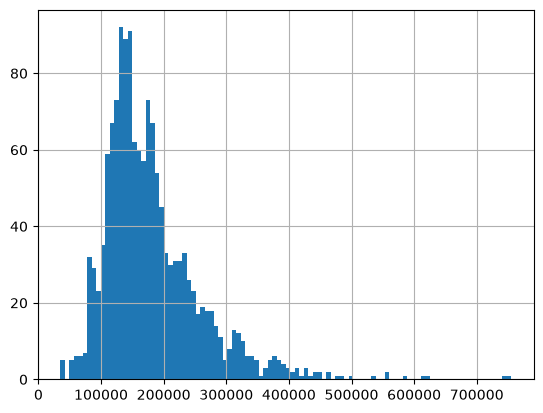

In [54]:
df["SalePrice"].hist(bins=100)
plt.show()

## GÜN 2

Detaylı EDA analizi veriyi daha yakından tanıma

In [55]:
sayisal_sutunlar = df.select_dtypes(include=["int64", "float64"]).columns.to_list()
print("Sayısal kolon sayısı:", len(sayisal_sutunlar))

Sayısal kolon sayısı: 38


In [56]:
kategorik_sutunlar = df.select_dtypes(include=["object", "str"]).columns.to_list()
print("Kategorik kolon sayısı:", len(kategorik_sutunlar))

Kategorik kolon sayısı: 43


In [57]:
df[sayisal_sutunlar].nunique().sort_values()

HalfBath            3
BsmtHalfBath        3
BsmtFullBath        4
FullBath            4
Fireplaces          4
KitchenAbvGr        4
GarageCars          5
YrSold              5
PoolArea            8
BedroomAbvGr        8
OverallCond         9
OverallQual        10
TotRmsAbvGrd       12
MoSold             12
MSSubClass         15
3SsnPorch          20
MiscVal            21
LowQualFinSF       24
YearRemodAdd       61
ScreenPorch        76
GarageYrBlt        97
LotFrontage       110
YearBuilt         112
EnclosedPorch     120
BsmtFinSF2        144
OpenPorchSF       202
WoodDeckSF        274
MasVnrArea        327
2ndFlrSF          417
GarageArea        441
BsmtFinSF1        637
SalePrice         663
TotalBsmtSF       721
1stFlrSF          753
BsmtUnfSF         780
GrLivArea         861
LotArea          1073
Id               1460
dtype: int64

In [58]:
df["MSSubClass"] = df["MSSubClass"].astype(str)

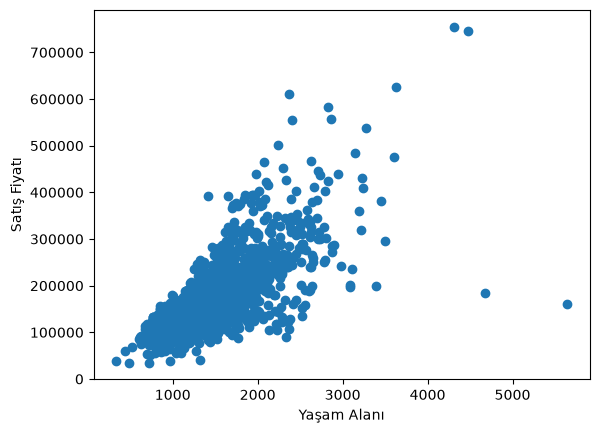

In [59]:
plt.scatter(df["GrLivArea"], df["SalePrice"])
plt.xlabel("Yaşam Alanı")
plt.ylabel("Satış Fiyatı")
plt.show()

In [60]:
corr = df[sayisal_sutunlar].corr()
corr = corr["SalePrice"]
corr = corr.sort_values(ascending=False)
corr.head(20)


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
Name: SalePrice, dtype: float64

## GÜN 3

In [61]:
import sys
sys.path.append("..")

In [62]:
from load.load import load_train, drop_unwanted_columns
df = load_train()
df = drop_unwanted_columns(df)
df.shape

(1460, 80)

In [63]:
from load.load import get_column_types
numeric_cols, categorical_cols = get_column_types(df)
print(len(numeric_cols), len(categorical_cols))

36 43


In [64]:
from load.load import split_features_target, train_val_split
X, y = split_features_target(df)
X_train, X_val, y_train, y_val = train_val_split(X, y)
print(X_train.shape, X_val.shape)

(1168, 79) (292, 79)


## GÜN 4

In [65]:
import sys
sys.path.append("..")

In [66]:
from clean.clean import fill_none_categoricals
df_test = fill_none_categoricals(df)
df_test[["PoolQC", "Alley", "FireplaceQu"]].isnull().sum()

PoolQC         0
Alley          0
FireplaceQu    0
dtype: int64

In [67]:
from clean.clean import fill_zero_numerics
df_test = fill_zero_numerics(df_test)
df_test[["GarageYrBlt", "TotalBsmtSF", "MasVnrArea"]].isnull().sum()


GarageYrBlt    0
TotalBsmtSF    0
MasVnrArea     0
dtype: int64

In [68]:
from clean.clean import NumericImputer, CategoricalImputer
num_imputer = NumericImputer(columns=["LotFrontage"])
X_train_filled = num_imputer.fit_transform(X_train)
X_val_filled = num_imputer.transform(X_val)

print("Öğrenilen median:", num_imputer.fill_values)
print("Train boş sayısı:", X_train_filled["LotFrontage"].isnull().sum())
print("Val boş sayısı:", X_val_filled["LotFrontage"].isnull().sum())

Öğrenilen median: {'LotFrontage': np.float64(70.0)}
Train boş sayısı: 0
Val boş sayısı: 0


In [69]:
cat_imputer = CategoricalImputer(columns=["Electrical"])
X_train_filled = cat_imputer.fit_transform(X_train_filled)
X_val_filled = cat_imputer.transform(X_val_filled)

print("Öğrenilen mode:", cat_imputer.fill_values)
print("Train boş sayısı:", X_train_filled["Electrical"].isnull().sum())
print("Val boş sayısı", X_val_filled["Electrical"].isnull().sum())

Öğrenilen mode: {'Electrical': 'SBrkr'}
Train boş sayısı: 0
Val boş sayısı 0


In [70]:
from clean.clean import DataCleaner
cleaner = DataCleaner()

X_train_clean = cleaner.fit_transform(X_train)
X_val_clean = cleaner.transform(X_val)

print("Train toplam boş hücre:", X_train_clean.isnull().sum().sum())
print("Val toplam boş hücre:", X_val_clean.isnull().sum().sum())

Train toplam boş hücre: 0
Val toplam boş hücre: 0


## GÜN 5

In [71]:
Q1 = df["GrLivArea"].quantile(0.25)
Q3 = df["GrLivArea"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR)
print("Alt sınır:", lower_bound, "üst sınır:", upper_bound)

outliers = df[(df["GrLivArea"] < lower_bound) | (df["GrLivArea"] > upper_bound)]
print("Outlier sayısı:", len(outliers))
outliers[["GrLivArea", "SalePrice"]]

Q1: 1129.5 Q3: 1776.75 IQR: 647.25
Alt sınır: 158.625 üst sınır: 2747.625
Outlier sayısı: 31


,GrLivArea,SalePrice
58,2945,438780
118,3222,320000
185,3608,475000
197,3112,235000
231,2794,403000
304,3493,295000
324,2978,242000
496,3228,430000
523,4676,184750
583,2775,325000


In [72]:
suspicious = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]
suspicious[["GrLivArea", "SalePrice"]]

,GrLivArea,SalePrice
523,4676,184750
1298,5642,160000


In [73]:
from clean.clean import remove_outliers
train_combined = X_train_clean.copy()
train_combined["SalePrice"] = y_train

print("Öncesi:", train_combined.shape)
train_combined = remove_outliers(train_combined)
print("Sonrası:", train_combined.shape)

X_train_final = train_combined.drop(columns=["SalePrice"])
y_train_final = train_combined["SalePrice"]

Öncesi: (1168, 80)
Sonrası: (1166, 80)


## GÜN 6

In [74]:
from clean.clean import encode_ordinal

X_train_ord = encode_ordinal(X_train_final)
X_train_ord[["KitchenQual", "BsmtExposure", "LotShape"]].head(10)

,KitchenQual,BsmtExposure,LotShape
254,3,1,4
1066,3,1,3
638,3,1,4
799,4,1,4
380,4,1,4
303,3,1,4
86,4,3,2
1385,4,1,4
265,4,1,3
793,4,3,4


In [75]:
# YANLIŞ YÖNTEM - sadece göstermek için, gerçek kodumuzda kullanmayacağız
train_sample = X_train_final[["Neighborhood"]].iloc[:100]
val_sample = X_val_clean[["Neighborhood"]].iloc[:100]

train_dummies = pd.get_dummies(train_sample)
val_dummies = pd.get_dummies(val_sample)

print("Train kolon sayısı:", train_dummies.shape[1])
print("Val kolon sayısı:", val_dummies.shape[1])
print("Train'de olup val'de olmayan:", set(train_dummies.columns) - set(val_dummies.columns))

Train kolon sayısı: 19
Val kolon sayısı: 21
Train'de olup val'de olmayan: {'Neighborhood_Blmngtn'}


In [76]:
from clean.clean import OneHotEncoderWrapper

ohe = OneHotEncoderWrapper()
X_train_ohe = ohe.fit_transform(X_train_ord)

X_val_ord = encode_ordinal(X_val_clean)
X_val_ohe = ohe.transform(X_val_ord)

print("Train shape:", X_train_ohe.shape)
print("Val shape:", X_val_ohe.shape)

Train shape: (1166, 258)
Val shape: (292, 258)


## GÜN 7

In [77]:
from clean.clean import ScalerWrapper

scaler = ScalerWrapper()
X_train_scaled = scaler.fit_transform(X_train_ohe)
X_val_scaled = scaler.transform(X_val_ohe)

X_train_scaled[["GrLivArea", "LotArea"]].describe()

,GrLivArea,LotArea
count,1.166000e+03,1.166000e+03
mean,-6.093849e-18,-6.398541e-17
std,1.000429e+00,1.000429e+00
min,-2.363944e+00,-8.778453e-01
25%,-7.485513e-01,-2.857180e-01
50%,-9.791396e-02,-9.597255e-02
75%,5.353000e-01,1.007203e-01
max,5.883768e+00,1.927610e+01


In [78]:
from clean.clean import FullPreprocessor, remove_outliers

# 1. Outlier temizliği (sadece train, X+y birlikte)
train_combined = X_train.copy()
train_combined["SalePrice"] = y_train
train_combined = remove_outliers(train_combined)
X_train_raw = train_combined.drop(columns=["SalePrice"])
y_train_final = train_combined["SalePrice"]

# 2. Tam ön işleme
preprocessor = FullPreprocessor()
X_train_ready = preprocessor.fit_transform(X_train_raw)
X_val_ready = preprocessor.transform(X_val)

print("X_train_ready:", X_train_ready.shape)
print("X_val_ready:", X_val_ready.shape)
print("Boş hücre (train):", X_train_ready.isnull().sum().sum())
print("Boş hücre (val):", X_val_ready.isnull().sum().sum())

X_train_ready: (1166, 258)
X_val_ready: (292, 258)
Boş hücre (train): 0
Boş hücre (val): 0


## GÜN 8

In [79]:
X_train_ready[["GarageCars", "GarageArea"]].corr()

,GarageCars,GarageArea
GarageCars,1.000000,0.888803
GarageArea,0.888803,1.000000


In [80]:
X_train_ready[["TotalBsmtSF", "1stFlrSF"]].corr()

,TotalBsmtSF,1stFlrSF
TotalBsmtSF,1.0000,0.8084
1stFlrSF,0.8084,1.0000


In [81]:
from clean.clean import drop_multicollinear

X_train_reduced = drop_multicollinear(X_train_ready)
X_val_reduced = drop_multicollinear(X_val_ready)

print(X_train_reduced.shape, X_val_reduced.shape)

(1166, 256) (292, 256)


In [82]:
"Id" in X_train_reduced.columns

False

In [83]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_reduced, y_train_final)

importances = pd.Series(rf.feature_importances_, index=X_train_reduced.columns)
importances.sort_values(ascending=False).head(20)

OverallQual     0.564310
GrLivArea       0.143169
TotalBsmtSF     0.052588
BsmtFinSF1      0.032047
LotArea         0.016832
2ndFlrSF        0.015431
BsmtQual        0.013280
GarageCars      0.012994
YearBuilt       0.011447
GarageYrBlt     0.007407
GarageFinish    0.007196
FullBath        0.007080
TotRmsAbvGrd    0.006937
YearRemodAdd    0.006709
LotFrontage     0.006452
KitchenQual     0.006405
FireplaceQu     0.004671
OpenPorchSF     0.004554
OverallCond     0.004351
WoodDeckSF      0.004272
dtype: float64

In [84]:
threshold = 0.001
low_importance_cols = importances[importances < threshold].index.tolist()

print("Elenecek kolon sayısı:", len(low_importance_cols))
print("Kalacak kolon sayısı:", len(importances) - len(low_importance_cols))

Elenecek kolon sayısı: 219
Kalacak kolon sayısı: 37


In [85]:
from clean.clean import FeatureSelector

selector = FeatureSelector()
X_train_selected = selector.fit_transform(X_train_reduced, y_train_final)
X_val_selected = selector.transform(X_val_reduced)

print(X_train_selected.shape, X_val_selected.shape)

(1166, 37) (292, 37)


## GÜN 9

In [86]:
import numpy as np

y_train_log = np.log1p(y_train_final)
y_val_log = np.log1p(y_val)

In [87]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    scores = cross_val_score(
        model, X_train_selected, y_train_log,
        cv=kf, scoring="neg_root_mean_squared_error"
    )
    rmse_scores = -scores
    results[name] = rmse_scores.mean()
    print(f"{name}: RMSE = {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")

Linear Regression: RMSE = 0.1227 (+/- 0.0047)
Ridge: RMSE = 0.1227 (+/- 0.0047)
Lasso: RMSE = 0.1223 (+/- 0.0050)
Random Forest: RMSE = 0.1354 (+/- 0.0044)
Gradient Boosting: RMSE = 0.1248 (+/- 0.0023)


In [88]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "alpha": [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
}

grid_search = GridSearchCV(
    Lasso(random_state=42),
    param_grid,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

grid_search.fit(X_train_selected, y_train_log)

print("En iyi alpha:", grid_search.best_params_)
print("En iyi RMSE:", -grid_search.best_score_)

En iyi alpha: {'alpha': 0.001}
En iyi RMSE: 0.12226060987199663


In [89]:
best_alpha = grid_search.best_params_["alpha"]

final_model = Lasso(alpha=best_alpha, random_state=42)
final_model.fit(X_train_selected, y_train_log)

from sklearn.metrics import mean_squared_error

y_val_pred_log = final_model.predict(X_val_selected)
val_rmse = np.sqrt(mean_squared_error(y_val_log, y_val_pred_log))

print("Validation RMSE (log ölçeğinde):", val_rmse)

y_val_pred = np.expm1(y_val_pred_log)
y_val_actual = np.expm1(y_val_log)
dollar_rmse = np.sqrt(mean_squared_error(y_val_actual, y_val_pred))

print("Validation RMSE (dolar cinsinden):", f"${dollar_rmse:,.0f}")

Validation RMSE (log ölçeğinde): 0.13566639987831475
Validation RMSE (dolar cinsinden): $23,338


In [90]:
from load.load import load_test
from model.model import predict_new_data

df_new = load_test()
print("Yeni veri shape:", df_new.shape)

predictions = predict_new_data(df_new)
print("İlk 10 tahmin:", predictions[:10])
print("Tahmin sayısı:", len(predictions))

Yeni veri shape: (1459, 80)
İlk 10 tahmin: [117093.67957791 158782.39360359 174265.91233907 199210.70700076
 185732.93295479 169275.08047607 180226.40165874 162250.00363804
 188102.72742334 116194.1135771 ]
Tahmin sayısı: 1459


In [91]:
from load.load import load_test
from model.model import predict_new_data

print("--- 🚀 TÜM TEST SETİ TAHMİNİ BAŞLIYOR ---")

# 1. 1459 satırlık test setinin TAMAMINI yüklüyoruz
test_veri = load_test()
print(f"\n[SİSTEM] Toplam {len(test_veri)} adet ev verisi yüklendi.")
print("[SİSTEM] Yapay zeka ajanımız tüm veriyi işliyor...")

# 2. Tüm veriyi tek seferde pipeline'a sokuyoruz
tahminler = predict_new_data(test_veri)

print("\n" + "="*50)
print("🎯 İLK 10 EVİN TAHMİN SONUCU")
print("="*50)

# Sonuçların ilk 10 tanesini düzgün bir formatta yazdırıyoruz
for i in range(10):
    ev_id = test_veri['Id'].iloc[i]
    print(f"Ev ID: {ev_id} -> Tahmini Fiyat: ${tahminler[i]:,.2f}")

print("="*50)
print(f"Başarıyla üretilen toplam tahmin sayısı: {len(tahminler)}")

--- 🚀 TÜM TEST SETİ TAHMİNİ BAŞLIYOR ---

[SİSTEM] Toplam 1459 adet ev verisi yüklendi.
[SİSTEM] Yapay zeka ajanımız tüm veriyi işliyor...

🎯 İLK 10 EVİN TAHMİN SONUCU
Ev ID: 1461 -> Tahmini Fiyat: $117,093.68
Ev ID: 1462 -> Tahmini Fiyat: $158,782.39
Ev ID: 1463 -> Tahmini Fiyat: $174,265.91
Ev ID: 1464 -> Tahmini Fiyat: $199,210.71
Ev ID: 1465 -> Tahmini Fiyat: $185,732.93
Ev ID: 1466 -> Tahmini Fiyat: $169,275.08
Ev ID: 1467 -> Tahmini Fiyat: $180,226.40
Ev ID: 1468 -> Tahmini Fiyat: $162,250.00
Ev ID: 1469 -> Tahmini Fiyat: $188,102.73
Ev ID: 1470 -> Tahmini Fiyat: $116,194.11
Başarıyla üretilen toplam tahmin sayısı: 1459


In [92]:
from load.load import load_test
from model.model import predict_new_data

df_new = load_test()
predictions = predict_new_data(df_new)
print(predictions[:10])
print(len(predictions))

[117093.67957791 158782.39360359 174265.91233907 199210.70700076
 185732.93295479 169275.08047607 180226.40165874 162250.00363804
 188102.72742334 116194.1135771 ]
1459


In [93]:
from model.model import load_artifacts

_, _, feature_selector = load_artifacts()
cols = feature_selector.selected_columns

print(f"Toplam seçilen sütun sayısı: {len(cols)}\n")
for c in sorted(cols):
    print(c)

Toplam seçilen sütun sayısı: 45

2ndFlrSF
BedroomAbvGr
BsmtExposure
BsmtFinSF1
BsmtFinType1
BsmtQual
BsmtUnfSF
CentralAir_N
CentralAir_Y
EnclosedPorch
ExterCond
ExterQual
FireplaceQu
Fireplaces
FullBath
GarageCars
GarageCond
GarageFinish
GarageQual
GarageType_Attchd
GarageType_Detchd
GarageYrBlt
GrLivArea
HeatingQC
KitchenAbvGr
KitchenQual
LotArea
LotFrontage
LotShape
MSSubClass_30
MSZoning_C (all)
MSZoning_RL
MSZoning_RM
MasVnrArea
OpenPorchSF
OverallCond
OverallQual
PavedDrive
SaleCondition_Abnorml
TotRmsAbvGrd
TotalBsmtSF
WoodDeckSF
YearBuilt
YearRemodAdd
YrSold


In [94]:
from model.model import load_artifacts

model, _, feature_selector = load_artifacts()
selected_cols = feature_selector.selected_columns

# Lasso'nun her seçili sütuna verdiği gerçek katsayı
coefs = dict(zip(selected_cols, model.coef_))

print("GarageType katsayıları:")
for col in selected_cols:
    if col.startswith("GarageType_"):
        print(f"  {col}: {coefs[col]:.2f}")

print("\nSıfır olmayan TÜM katsayılar (mutlak değere göre sıralı):")
nonzero = {k: v for k, v in coefs.items() if abs(v) > 1e-6}
for col, val in sorted(nonzero.items(), key=lambda x: -abs(x[1])):
    print(f"  {col:30s} {val:10.2f}")

print(f"\nToplam seçili sütun: {len(selected_cols)}")
print(f"Lasso'nun gerçekten kullandığı (katsayısı ≠ 0): {len(nonzero)}")

GarageType katsayıları:
  GarageType_Attchd: -0.00
  GarageType_Detchd: 0.00

Sıfır olmayan TÜM katsayılar (mutlak değere göre sıralı):
  MSZoning_C (all)                    -0.21
  GrLivArea                            0.13
  OverallQual                          0.08
  MSZoning_RM                         -0.08
  SaleCondition_Abnorml               -0.07
  YearBuilt                            0.05
  TotalBsmtSF                          0.05
  OverallCond                          0.05
  GarageCars                           0.04
  BsmtFinSF1                           0.03
  CentralAir_N                        -0.03
  MSSubClass_30                       -0.03
  LotArea                              0.02
  KitchenQual                          0.02
  FireplaceQu                          0.02
  HeatingQC                            0.02
  ExterQual                            0.01
  YearRemodAdd                         0.01
  BsmtExposure                         0.01
  LotFrontage               